# HPA Usage

## Preparando o ambiente

In [1]:
import utils
import os
import glob
import time
import re
import json
import requests
import yaml
from pathlib import Path
from datetime import datetime, timedelta
from zoneinfo import ZoneInfo

from concurrent.futures import ThreadPoolExecutor, as_completed
from dotenv import dotenv_values
from ghapi.core import GhApi, HTTP422UnprocessableEntityError, HTTP404NotFoundError, HTTP403ForbiddenError
import fastcore
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
plt.style.use('bmh')


In [2]:
config = {
    **os.environ,
    **dotenv_values(".env")
}
github = GhApi(token=config['GITHUB_TOKEN'])


In [3]:
gh_limit = github.rate_limit.get()

print(int(datetime.timestamp(datetime.now())),
      datetime.now().replace(microsecond=0))
print(gh_limit['resources']['search']['reset'],
      datetime.fromtimestamp(gh_limit['resources']['search']['reset']))
display(gh_limit['resources'])


1746132051 2025-05-01 17:40:51
1746132111 2025-05-01 17:41:51


```json
{ 'actions_runner_registration': { 'limit': 10000,
                                   'remaining': 10000,
                                   'reset': 1746135651,
                                   'used': 0},
  'audit_log': { 'limit': 1750,
                 'remaining': 1750,
                 'reset': 1746135651,
                 'used': 0},
  'audit_log_streaming': { 'limit': 15,
                           'remaining': 15,
                           'reset': 1746135651,
                           'used': 0},
  'code_scanning_autofix': { 'limit': 10,
                             'remaining': 10,
                             'reset': 1746132111,
                             'used': 0},
  'code_scanning_upload': { 'limit': 5000,
                            'remaining': 4993,
                            'reset': 1746133889,
                            'used': 7},
  'code_search': {'limit': 10, 'remaining': 10, 'reset': 1746132111, 'used': 0},
  'core': {'limit': 5000, 'remaining': 4993, 'reset': 1746133889, 'used': 7},
  'dependency_snapshots': { 'limit': 100,
                            'remaining': 100,
                            'reset': 1746132111,
                            'used': 0},
  'graphql': {'limit': 5000, 'remaining': 5000, 'reset': 1746135651, 'used': 0},
  'integration_manifest': { 'limit': 5000,
                            'remaining': 5000,
                            'reset': 1746135651,
                            'used': 0},
  'scim': {'limit': 15000, 'remaining': 15000, 'reset': 1746135651, 'used': 0},
  'search': {'limit': 30, 'remaining': 30, 'reset': 1746132111, 'used': 0},
  'source_import': { 'limit': 100,
                     'remaining': 100,
                     'reset': 1746132111,
                     'used': 0}}
```

## Function Definitions

In [3]:
def wait_for_reset(resource):
    limit = github.rate_limit.get()['resources'][resource]
    reset_time = datetime.fromtimestamp(limit['reset'])
    now = datetime.today().replace(microsecond=0)
    if limit['remaining'] <= 1:
        sleep_duration = reset_time - now
        if sleep_duration.total_seconds() < 0:
            sleep_duration = timedelta(seconds=60)
        print(
            f"Waiting for {sleep_duration.total_seconds()} seconds until {reset_time}")
        time.sleep(sleep_duration.total_seconds() + 1)


def search_code_hpa():
    result_items = []
    page = 1

    # search_result acumula cada página da pesquisa
    search_result = None

    # Carrega as páginas da pesquisa
    while search_result is None or len(result_items) < search_result['total_count']:
        wait_for_reset('code_search')
        print(f"Loading page {page}")
        time.sleep(1)
        try:
            search_result = github.search.code(
                q='"kind: HorizontalPodAutoscaler" language:yaml', per_page=100, page=page)
            result_items.extend(search_result['items'])
            page += 1
        except HTTP422UnprocessableEntityError as e:
            return result_items


def get_repo_details(row):
    wait_for_reset('core')
    name_parts = re.split(r'/', row['repo_name'])

    try:
        repo_details = github.repos.get(
            owner=name_parts[0], repo=name_parts[1])
        data = {
            'stargazers_count': repo_details['stargazers_count'],
            'created_at': repo_details['created_at'],
            'pushed_at': repo_details['pushed_at']
        }
    except HTTP403ForbiddenError:
        print("Limit reached")
        wait_for_reset('core')
        repo_details = github.repos.get(
            owner=name_parts[0], repo=name_parts[1])
        data = {
            'stargazers_count': repo_details['stargazers_count'],
            'created_at': repo_details['created_at'],
            'pushed_at': repo_details['pushed_at']
        }
    except (HTTP404NotFoundError, fastcore.net.HTTP404NotFoundError):
        data = {
            'stargazers_count': pd.NA,
            'created_at': pd.NA,
            'pushed_at': pd.NA
        }

    return pd.Series(data, name=row.name)


def get_file_commit(row):
    wait_for_reset('core')
    name_parts = re.split(r'/', row['repo_name'])

    try:
        commits = github.repos.list_commits(
            owner=name_parts[0], repo=name_parts[1], path=row['file_path'], per_page=1)
    except HTTP403ForbiddenError:
        print("Limit reached")
        wait_for_reset('core')
        commits = github.repos.list_commits(
            owner=name_parts[0], repo=name_parts[1], path=row['file_path'], per_page=1)
    except (HTTP404NotFoundError, fastcore.net.HTTP404NotFoundError):
        return {
            'file_committed_at': None,
            'message': None
        }

    if len(commits) == 0:
        return {
            'file_committed_at': None,
            'message': None
        }

    return {
        'file_committed_at': commits[0]['commit']['author']['date'],
        'message': commits[0]['commit']['message']
    }


def extract_hpa(yaml_content):
    hpa_list = []
    for doc in yaml_content:
        if isinstance(doc, dict) and doc.get('kind') == "HorizontalPodAutoscaler":
            hpa_list.append(doc)
    return hpa_list


def download_hpa_spec(item):
    if not os.path.isdir('search_results'):
        os.mkdir('search_results')

    response = requests.get(item['url'])
    if response.status_code == 200:

        # Tries to remove Helm Template marks
        clean_text = re.sub(r'{{-.*?}}', '', response.text)
        clean_text = re.sub(r'{{.*?}}', 'helm_command', clean_text)

        yaml_content = list(yaml.safe_load_all(clean_text))
        hpa_content = extract_hpa(yaml_content)
        if hpa_content is None:
            return

        target_path = Path(
            "search_results", item['repo_name'], item['file_path'])
        target_path.parent.mkdir(parents=True, exist_ok=True)

        with open(target_path, 'w') as file:
            file.write(yaml.dump_all(hpa_content))
    else:
        print(f"Loading {url} returned {response.status_code}")


def download_file(row):
    url = row['url']
    repo_name = row['repo_name']
    file_path = row['file_path']
    
    if not os.path.isdir('search_results'):
        os.mkdir('search_results')

    response = requests.get(url.replace('/blob/', '/raw/'))
    if response.status_code == 200:
        target_path = Path("search_results", repo_name, file_path)
        target_path.parent.mkdir(parents=True, exist_ok=True)
        with open(target_path, 'w') as dest:
            dest.write(response.text)
    else:
        print(f'Loading {url} returned {response.status_code}')


# Performs the Search

In [6]:
search_items = []
result_items = search_code_hpa()
for item in result_items:
    search_items.append({
        'repo_name': item['repository']['full_name'],
        'file_path': item['path'],
        'url': item['html_url']
    })

Loading page 1
Loading page 2
Loading page 3
Loading page 4
Loading page 5
Loading page 6
Loading page 7
Loading page 8
Loading page 9
Loading page 10
Loading page 11


In [7]:
items = pd.DataFrame(search_items)

display(items)
print(
    f"Found {items.shape[0]} files in {len(items['repo_name'].unique())} repositories")


,repo_name,file_path,url
0,chronolaw/k8s_study,ch4/hpa.yml,https://github.com/chronolaw/k8s_study/blob/1e...
1,krestomatio/moodle-operator,watches.yaml,https://github.com/krestomatio/moodle-operator...
2,lidorg-dev/k8s-class-demo,hpa.yaml,https://github.com/lidorg-dev/k8s-class-demo/b...
3,fiap-postech-orion/tech-challenge-api-produto,k8s/app.yaml,https://github.com/fiap-postech-orion/tech-cha...
4,imdadMahammed/Useful-Kubernetes-Manifests,HPA_DOC.yml,https://github.com/imdadMahammed/Useful-Kubern...
...,...,...,...
995,wayoos/kubedash,backend/tmp_deployments/depr-chart/templates/h...,https://github.com/wayoos/kubedash/blob/1f368c...
996,arman-shafiei/snapp-task,application/manifests/hpa.yaml,https://github.com/arman-shafiei/snapp-task/bl...
997,denisber1984/kubernetes-project,my-nginx-app-chart/templates/nginx-hpa.yaml,https://github.com/denisber1984/kubernetes-pro...
998,PMprojetos/Projeto-de-Escalonamento,autoscaler/hpa.yml,https://github.com/PMprojetos/Projeto-de-Escal...


Found 1000 files in 874 repositories


## Saves Phase 1

In [7]:
utils.save_phase1_results(items)


## Loads all Phase 1 files

In [8]:
items = utils.load_phase1_results()

display(items.info())

print(
    f"Found {items.shape[0]} files in {len(items['repo_name'].unique())} repositories")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4992 entries, 0 to 4991
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   repo_name  4992 non-null   object
 1   file_path  4992 non-null   object
 2   url        4992 non-null   object
dtypes: object(3)
memory usage: 117.1+ KB


None

Found 4992 files in 3630 repositories


## Additional Data
### stargazers_count, Creation Date and Last Push on repo

In [82]:
# Uses ThreadPoolExecutor to call get_repo_details in parallel jobs

repos_details = []

with ThreadPoolExecutor(max_workers=32) as pool:
    future_to_idx = {
        pool.submit(get_repo_details, row): idx
        for idx, row in items.iterrows()
    }

    for fut in as_completed(future_to_idx):
        repos_details.append(fut.result())

# repos_details = [get_repo_details(row) for _, row in items.iterrows()]

display(repos_details)


Limit reachedLimit reached
Limit reached

Limit reached
Limit reached
Limit reached
Limit reached
Waiting for 3309.0 seconds until 2025-05-01 17:11:28
Waiting for 3309.0 seconds until 2025-05-01 17:11:28
Waiting for 3309.0 seconds until 2025-05-01 17:11:28
Waiting for 3309.0 seconds until 2025-05-01 17:11:28
Waiting for 3309.0 seconds until 2025-05-01 17:11:28
Waiting for 3309.0 seconds until 2025-05-01 17:11:28
Waiting for 3309.0 seconds until 2025-05-01 17:11:28


[stargazers_count    <NA>
 created_at          <NA>
 pushed_at           <NA>
 Name: 20, dtype: object,
 stargazers_count    <NA>
 created_at          <NA>
 pushed_at           <NA>
 Name: 21, dtype: object,
 stargazers_count                       0
 created_at          2023-08-03T03:34:49Z
 pushed_at           2023-08-03T05:39:07Z
 Name: 3, dtype: object,
 stargazers_count                       2
 created_at          2023-09-07T09:38:37Z
 pushed_at           2023-12-03T08:57:50Z
 Name: 15, dtype: object,
 stargazers_count                      12
 created_at          2021-12-03T12:16:25Z
 pushed_at           2025-04-30T09:05:51Z
 Name: 18, dtype: object,
 stargazers_count                       0
 created_at          2023-09-04T04:09:53Z
 pushed_at           2023-09-12T21:27:58Z
 Name: 29, dtype: object,
 stargazers_count                       1
 created_at          2023-11-16T19:27:46Z
 pushed_at           2024-04-12T04:28:20Z
 Name: 25, dtype: object,
 stargazers_count                

In [90]:
df_details = pd.DataFrame(repos_details)
display(df_details.info())

display(df_details[df_details['stargazers_count'].isna()])


<class 'pandas.core.frame.DataFrame'>
Index: 4992 entries, 20 to 4991
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   stargazers_count  4931 non-null   object
 1   created_at        4931 non-null   object
 2   pushed_at         4931 non-null   object
dtypes: object(3)
memory usage: 156.0+ KB


None

,stargazers_count,created_at,pushed_at
20,<NA>,<NA>,<NA>
21,<NA>,<NA>,<NA>
74,<NA>,<NA>,<NA>
126,<NA>,<NA>,<NA>
132,<NA>,<NA>,<NA>
...,...,...,...
4228,<NA>,<NA>,<NA>
4241,<NA>,<NA>,<NA>
4485,<NA>,<NA>,<NA>
4671,<NA>,<NA>,<NA>


In [91]:
items_details = items.join([df_details])

display(items_details)


,repo_name,file_path,url,stargazers_count,created_at,pushed_at
0,01-edu/orchestrator,manifests/inventory-app.yaml,https://github.com/01-edu/orchestrator/blob/87...,0,2023-11-28T17:34:39Z,2024-01-15T09:15:33Z
1,0GiS0/tour-of-heroes-gitops-demos,helm/tour-of-heroes-chart/charts/api/templates...,https://github.com/0GiS0/tour-of-heroes-gitops...,2,2022-05-02T18:37:39Z,2023-08-01T07:52:38Z
2,0hlov3/charts,charts/element-web/templates/hpa.yaml,https://github.com/0hlov3/charts/blob/daca391f...,4,2023-04-17T06:54:36Z,2025-04-25T05:17:10Z
3,0nebody/charts,stable/benth/templates/hpa.yaml,https://github.com/0nebody/charts/blob/1ed4ad1...,0,2023-08-03T03:34:49Z,2023-08-03T05:39:07Z
4,0xhappyboy/react-template,market-template-1/hokusai/staging.yml,https://github.com/0xhappyboy/react-template/b...,0,2022-12-21T08:50:49Z,2023-01-21T16:25:12Z
...,...,...,...,...,...,...
4987,zquestz/reapers.cash,kube/reapers-autoscale.yml,https://github.com/zquestz/reapers.cash/blob/7...,1,2022-01-08T04:54:17Z,2024-11-14T00:06:41Z
4988,zsmn/k8scd,k8s/config/istio/istio-ingress.yaml,https://github.com/zsmn/k8scd/blob/7830475ad18...,1,2024-05-01T12:56:19Z,2025-02-23T15:58:40Z
4989,zuc/helm-charts,charts/outline/templates/hpa.yaml,https://github.com/zuc/helm-charts/blob/d28af2...,1,2020-06-22T15:09:56Z,2021-05-14T19:57:31Z
4990,zuisong/vertx-server-push,k8s.yml,https://github.com/zuisong/vertx-server-push/b...,3,2021-03-08T07:59:57Z,2025-04-28T06:22:51Z


### Remove items from repositores that no more exist


In [92]:
display(items_details[items_details['stargazers_count'].isna()].shape[0])


61

In [94]:
items_details.dropna(subset=['stargazers_count'],
                     inplace=True, ignore_index=True)

display(items_details.shape[0])

items_details.to_csv(
    f"partial_results/{datetime.now().replace(microsecond=0).isoformat()}-phase2.csv", index=False)


4931

In [96]:
items_details = utils.load_phase2_results()

print(f"Loaded {items_details.shape[0]} items")

print(f"{items_details['repo_name'].unique().shape[0]} unique repositories")

items_details['created_at'] = pd.to_datetime(items_details['created_at'])
items_details['pushed_at'] = pd.to_datetime(items_details['pushed_at'])
display(items_details)


Loaded 4931 items
3584 unique repositories


,repo_name,file_path,url,stargazers_count,created_at,pushed_at
0,01-edu/orchestrator,manifests/inventory-app.yaml,https://github.com/01-edu/orchestrator/blob/87...,0,2023-11-28 17:34:39+00:00,2024-01-15 09:15:33+00:00
1,0GiS0/tour-of-heroes-gitops-demos,helm/tour-of-heroes-chart/charts/api/templates...,https://github.com/0GiS0/tour-of-heroes-gitops...,2,2022-05-02 18:37:39+00:00,2023-08-01 07:52:38+00:00
2,0hlov3/charts,charts/element-web/templates/hpa.yaml,https://github.com/0hlov3/charts/blob/daca391f...,4,2023-04-17 06:54:36+00:00,2025-04-25 05:17:10+00:00
3,0nebody/charts,stable/benth/templates/hpa.yaml,https://github.com/0nebody/charts/blob/1ed4ad1...,0,2023-08-03 03:34:49+00:00,2023-08-03 05:39:07+00:00
4,0xhappyboy/react-template,market-template-1/hokusai/staging.yml,https://github.com/0xhappyboy/react-template/b...,0,2022-12-21 08:50:49+00:00,2023-01-21 16:25:12+00:00
...,...,...,...,...,...,...
4926,zquestz/reapers.cash,kube/reapers-autoscale.yml,https://github.com/zquestz/reapers.cash/blob/7...,1,2022-01-08 04:54:17+00:00,2024-11-14 00:06:41+00:00
4927,zsmn/k8scd,k8s/config/istio/istio-ingress.yaml,https://github.com/zsmn/k8scd/blob/7830475ad18...,1,2024-05-01 12:56:19+00:00,2025-02-23 15:58:40+00:00
4928,zuc/helm-charts,charts/outline/templates/hpa.yaml,https://github.com/zuc/helm-charts/blob/d28af2...,1,2020-06-22 15:09:56+00:00,2021-05-14 19:57:31+00:00
4929,zuisong/vertx-server-push,k8s.yml,https://github.com/zuisong/vertx-server-push/b...,3,2021-03-08 07:59:57+00:00,2025-04-28 06:22:51+00:00


In [97]:
print("All the results")
print(items_details['stargazers_count'].describe())

min_stars = 1
print(f"\nMinimum {min_stars} stargazers_count")
filter_min_stars = items_details[items_details['stargazers_count'] > min_stars]
print(filter_min_stars['stargazers_count'].describe())


All the results
count     4931.000000
mean       192.047455
std       1459.281851
min          0.000000
25%          0.000000
50%          0.000000
75%          4.000000
max      29747.000000
Name: stargazers_count, dtype: float64

Minimum 1 stargazers_count
count     1638.000000
mean       577.805861
std       2488.023360
min          2.000000
25%          4.000000
50%         14.000000
75%         83.000000
max      29747.000000
Name: stargazers_count, dtype: float64


In [98]:
print(f"{filter_min_stars['repo_name'].unique().shape[0]} unique repositories")


925 unique repositories


# Analysing stargazers_count

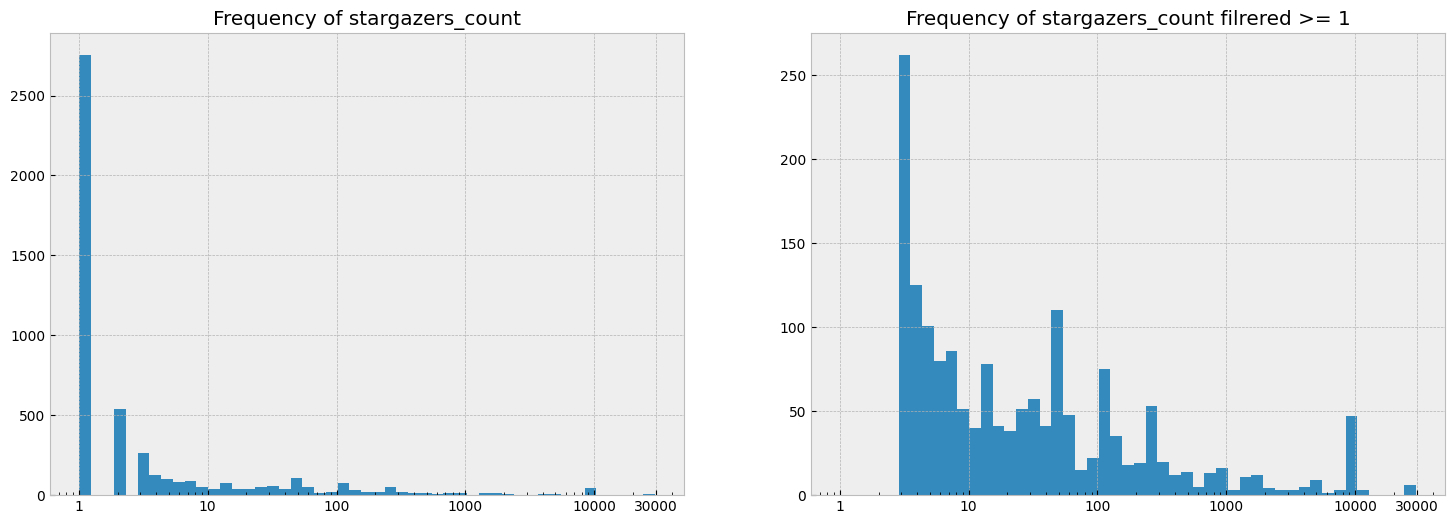

In [99]:
plt.style.use('bmh')
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

data_full = items_details['stargazers_count']
data_filter = filter_min_stars['stargazers_count']

bins_full = np.logspace(0, np.log10(data_full.max() + 1), 50)
bins_filter = np.logspace(0, np.log10(data_filter.max() + 1), 50)

ticks = [1, 10, 100, 1000, 10000, 30000]

axes[0].hist(data_full + 1, bins=bins_full)
axes[0].set_xscale('log')
axes[0].set_xticks(ticks, ticks)
axes[0].set_title("Frequency of stargazers_count")

axes[1].hist(data_filter + 1, bins=bins_filter)
axes[1].set_xscale('log')
axes[1].set_xticks(ticks, ticks)
axes[1].set_title(f"Frequency of stargazers_count filrered >= {min_stars}")

plt.show()


# Analisando created_at e pushed_at

In [100]:
created_at = pd.to_datetime(items_details['created_at'])
pushed_at = pd.to_datetime(items_details['pushed_at'])

print(f"Oldest repository by created_at:\t{created_at.min()}\n\
Newest repository by created_at:\t{created_at.max()}")

print(f"Most dormant repository by pushed_at:\t{pushed_at.min()}\n\
Newest updated repository by puhsed_at:\t{pushed_at.max()}")


Oldest repository by created_at:	2011-10-27 05:58:15+00:00
Newest repository by created_at:	2025-03-18 00:12:08+00:00
Most dormant repository by pushed_at:	2015-12-01 23:05:53+00:00
Newest updated repository by puhsed_at:	2025-05-01 19:12:03+00:00


In [101]:
items_details['life_span'] = items_details['pushed_at'] - \
    items_details['created_at']

display(items_details[items_details['life_span']
        == items_details['life_span'].min()])

display(items_details['life_span'].describe())

min_days = 180
print(f"\nMinimum of {min_days} days")
filter_min_days = items_details[items_details['life_span'].dt.days > min_days]
print(filter_min_days['life_span'].describe())

,repo_name,file_path,url,stargazers_count,created_at,pushed_at,life_span
4901,zccfzcc/docker-images,prometheus/production/example-app/example-app-...,https://github.com/zccfzcc/docker-images/blob/...,0,2019-09-18 02:54:06+00:00,2019-04-24 09:33:37+00:00,-147 days +06:39:31


count                           4931
mean     558 days 08:40:33.920705736
std      758 days 03:37:47.632054992
min              -147 days +06:39:31
25%                 15 days 17:10:02
50%                175 days 18:03:52
75%                861 days 03:05:41
max               4662 days 18:25:04
Name: life_span, dtype: object


Minimum of 180 days
count                            2454
mean     1082 days 14:45:14.831703328
std       778 days 02:15:26.452089984
min                 182 days 01:20:12
25%                 449 days 22:19:14
50%                 873 days 15:05:30
75%         1531 days 04:16:28.250000
max                4662 days 18:25:04
Name: life_span, dtype: object


In [102]:
display(items_details['pushed_at'].describe())

limit_oldest_pushed_at = (datetime.today() - timedelta(days=360)).replace(
    hour=0, minute=0, second=0, microsecond=0, tzinfo=ZoneInfo('GMT'))
print(f"\npushed_at newer than {limit_oldest_pushed_at}")
filter_newer_pushed_at = items_details[items_details['pushed_at']
                                       > limit_oldest_pushed_at]
print(filter_newer_pushed_at['pushed_at'].describe())


count                                   4931
mean     2024-02-14 20:57:57.695396352+00:00
min                2015-12-01 23:05:53+00:00
25%                2023-08-01 16:29:32+00:00
50%                2024-09-03 10:45:00+00:00
75%         2025-04-07 10:35:43.500000+00:00
max                2025-05-01 19:12:03+00:00
Name: pushed_at, dtype: object


pushed_at newer than 2024-05-06 00:00:00+00:00
count                                   3028
mean     2025-01-10 10:19:12.408190208+00:00
min                2024-05-06 02:17:22+00:00
25%      2024-10-05 15:41:06.750000128+00:00
50%                2025-02-14 16:04:35+00:00
75%                2025-04-29 04:10:32+00:00
max                2025-05-01 19:12:03+00:00
Name: pushed_at, dtype: object


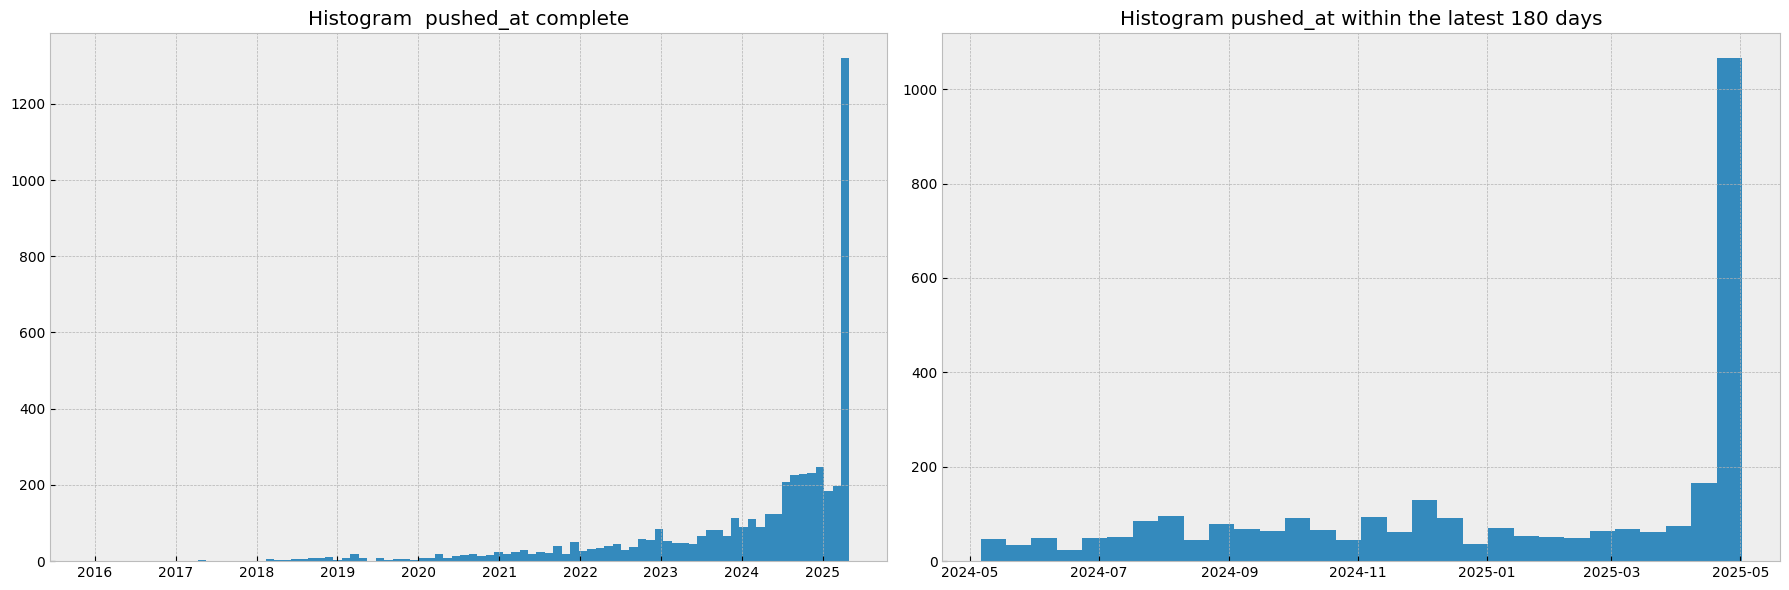

In [103]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

data_full = items_details['pushed_at']
data_filter = filter_newer_pushed_at['pushed_at']

# bins_full = np.logspace(0, np.log10(data_full.max() + 1), 50)
# bins_filter = np.logspace(0, np.log10(data_filter.max() + 1), 50)

ticks = [1, 10, 100, 1000, 10000, 30000]

axes[0].hist(data_full, bins=90)
# axes[0].set_xticks(ticks, ticks)
axes[0].set_title("Histogram  pushed_at complete")

axes[1].hist(data_filter, bins=30)
# axes[1].set_xticks(ticks, ticks)
axes[1].set_title("Histogram pushed_at within the latest 180 days")

plt.tight_layout()
plt.show()


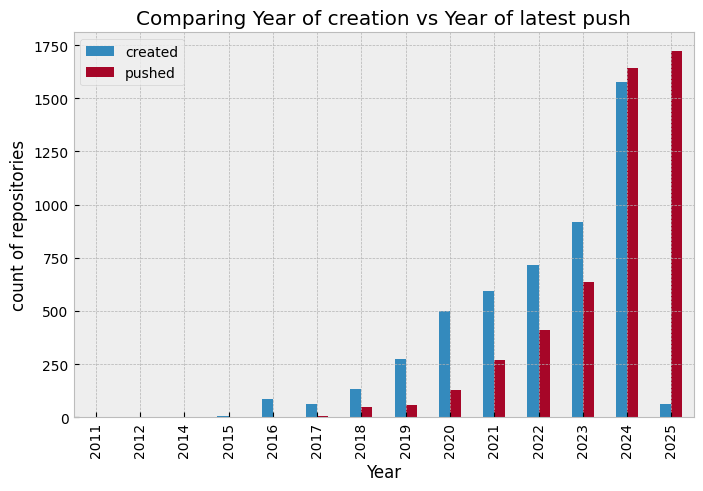

In [104]:
items_details['created_at'] = pd.to_datetime(items_details['created_at'])
items_details['pushed_at'] = pd.to_datetime(items_details['pushed_at'])

items_details['created_year'] = items_details['created_at'].dt.year
items_details['pushed_year'] = items_details['pushed_at'].dt.year

created_year_count = items_details.groupby('created_year')['repo_name'].count()
pushed_year_count = items_details.groupby('pushed_year')['repo_name'].count()

df_anos = pd.DataFrame({
    'created': created_year_count,
    'pushed': pushed_year_count
})

df_anos.plot(kind='bar', figsize=(8, 5))
plt.title('Comparing Year of creation vs Year of latest push')
plt.xlabel('Year')
plt.ylabel('count of repositories')
plt.show()


# Filtering by stargazers_count

In [105]:
filtered_items = filter_min_stars.sort_values(by=['stargazers_count'])
filtered_items


,repo_name,file_path,url,stargazers_count,created_at,pushed_at
4840,wutthichai46/-GitHub,tools/k8s/devops/helm-charts/tensorflow-servin...,https://github.com/wutthichai46/-GitHub/blob/2...,2,2022-05-12 08:17:49+00:00,2022-05-12 08:19:17+00:00
4839,wusted/kubernetes-install,24-hpa-all-metrics/04-hello-hpa-pods.yaml,https://github.com/wusted/kubernetes-install/b...,2,2021-10-04 00:31:02+00:00,2023-03-09 03:58:13+00:00
4833,wrasdf/kube-test,templates/onboarding/hpa.yaml,https://github.com/wrasdf/kube-test/blob/1da94...,2,2018-03-29 12:30:35+00:00,2023-05-22 23:55:20+00:00
4831,woolrab6/upgraded-pi,kubernetes/config/app.yaml,https://github.com/woolrab6/upgraded-pi/blob/7...,2,2022-08-25 14:55:30+00:00,2023-10-17 05:52:12+00:00
87,AlexRogalskiy/scala-patterns,k8s/secure/backend/hpa.yaml,https://github.com/AlexRogalskiy/scala-pattern...,2,2020-12-13 06:47:41+00:00,2025-05-01 04:43:17+00:00
...,...,...,...,...,...,...
176,Budibase/budibase,charts/budibase/templates/automation-worker-se...,https://github.com/Budibase/budibase/blob/8a11...,24424,2019-06-07 11:03:41+00:00,2025-05-01 15:51:05+00:00
175,Budibase/budibase,charts/budibase/templates/automation-worker-se...,https://github.com/Budibase/budibase/blob/1328...,24424,2019-06-07 11:03:41+00:00,2025-05-01 15:51:05+00:00
2444,grafana/loki,production/helm/loki/templates/querier/hpa.yaml,https://github.com/grafana/loki/blob/8fd8697b9...,25311,2018-04-16 09:22:48+00:00,2025-05-01 19:11:13+00:00
4624,transloadit/uppy,packages/@uppy/companion/infra/kube/companion/...,https://github.com/transloadit/uppy/blob/ead58...,29747,2015-11-16 12:32:33+00:00,2025-04-30 12:42:13+00:00


In [106]:
timestamp = datetime.now().replace(microsecond=0).isoformat()
filter_min_stars.to_csv(f"partial_results/{timestamp}-phase3.csv", index=False)

In [4]:
phase3 = utils.load_phase3_results()

phase3

,repo_name,file_path,url,stargazers_count,created_at,pushed_at
0,0GiS0/tour-of-heroes-gitops-demos,helm/tour-of-heroes-chart/charts/api/templates...,https://github.com/0GiS0/tour-of-heroes-gitops...,2,2022-05-02 18:37:39+00:00,2023-08-01 07:52:38+00:00
1,0hlov3/charts,charts/element-web/templates/hpa.yaml,https://github.com/0hlov3/charts/blob/daca391f...,4,2023-04-17 06:54:36+00:00,2025-04-25 05:17:10+00:00
2,18F/identity-dashboard,dockerfiles/application.yaml,https://github.com/18F/identity-dashboard/blob...,25,2016-05-09 21:23:58+00:00,2025-05-01 19:02:39+00:00
3,18F/identity-dashboard,dockerfiles/application.yaml,https://github.com/18F/identity-dashboard/blob...,25,2016-05-09 21:23:58+00:00,2025-05-01 19:02:39+00:00
4,18F/identity-dashboard,dockerfiles/application.yaml,https://github.com/18F/identity-dashboard/blob...,25,2016-05-09 21:23:58+00:00,2025-05-01 19:02:39+00:00
...,...,...,...,...,...,...
1633,zhaodangxue/Minik8s,controller/src/HPAController/test/hpa-example....,https://github.com/zhaodangxue/Minik8s/blob/b1...,3,2024-07-03 07:37:00+00:00,2024-07-11 14:33:04+00:00
1634,zhaodangxue/Minik8s,apiobjects/examples/pod/hpa-example.yaml,https://github.com/zhaodangxue/Minik8s/blob/b1...,3,2024-07-03 07:37:00+00:00,2024-07-11 14:33:04+00:00
1635,zjzjzjzj1874/best-practice-go-zero,task/task-k8s.yaml,https://github.com/zjzjzjzj1874/best-practice-...,10,2022-06-06 09:46:12+00:00,2025-04-07 02:07:30+00:00
1636,zuisong/vertx-server-push,k8s.yml,https://github.com/zuisong/vertx-server-push/b...,3,2021-03-08 07:59:57+00:00,2025-04-28 06:22:51+00:00


In [5]:
with ThreadPoolExecutor(max_workers=16) as pool:
    future = {
        pool.submit(download_file, row): idx
        for idx, row in phase3.iterrows()
    }

# for _, row in filter_min_stars.iterrows():
#   download_file(row)
